# Кривые обучения (Learning Curves) — введение


Если использовать полиномиальную регрессию **высокой степени**, модель подгонится под тренировочные данные намного точнее, чем обычная линейная регрессия.

**Пример (см. график выше, Figure 4-14)**: сравнили 3 модели на одних и тех же данных:
- **1 degree** (красная, прямая линия) — слишком простая
- **2 degrees** (синяя пунктирная, парабола) — хорошо легла на данные
- **300 degrees** (зелёная, дикие "змейки") — модель извивается, стараясь пройти как можно ближе к каждой отдельной точке

![4-14-img](./4-14.png)

## Два состояния модели

- **Overfitting (переобучение)** — модель 300 степени: слишком сложная, "запомнила" шум вместо общей закономерности.
- **Underfitting (недообучение)** — линейная модель (1 степень): слишком простая, не может уловить изгиб данных.
- **Хорошо обученная** — квадратичная модель (2 степени): именно она лучше всего обобщает, что логично — данные изначально генерировались по квадратичной формуле.

## Главный вопрос

На практике мы **не знаем**, какой сложности должна быть модель (не знаем, по какой формуле изначально сгенерированы реальные данные). Как понять, что модель переобучена или недообучена?

## Способ 1 (уже известный) — кросс-валидация

Если модель хорошо работает на тренировочных данных, но плохо — по метрикам кросс-валидации → **переобучение**.
Если плохо работает и там, и там → **недообучение**.

## Способ 2 (новый) — кривые обучения (learning curves)

Это графики **ошибки на тренировочных данных** и **ошибки на валидационных данных** в зависимости от размера тренировочного набора.

Как это строится: модель обучается заново на всё увеличивающихся кусках тренировочного набора (например: сначала на первых 5 объектах, потом на первых 10, потом на 15, и так далее), и на каждом шаге замеряется ошибка — отдельно на тренировочных данных, отдельно на валидационных.

Если модель не поддерживает инкрементальное обучение (`partial_fit()` или `warm_start`) — приходится обучать её **заново с нуля** много раз, каждый раз на всё большем куске данных.

**Для этого в sklearn есть готовая функция `learning_curve()`**, которая всё это делает автоматически, используя кросс-валидацию:
- по умолчанию — переобучает модель на увеличивающихся подвыборках
- если модель поддерживает инкрементальное обучение, можно поставить `exploit_incremental_learning=True`, и тогда она будет дообучаться постепенно, а не с нуля

Функция возвращает: размеры тренировочных наборов, на которых оценивалась модель, и ошибки (train/validation) для каждого размера и каждого фолда кросс-валидации.


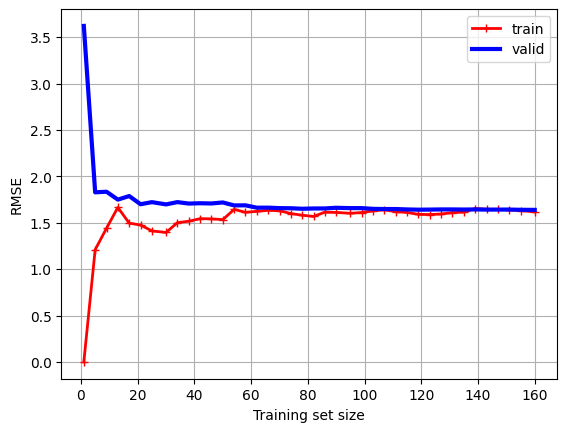

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))

# На каждом шаге обучаем, замеряем ошибки, отдельно на тренировачных и отдельно валидационных
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X,
    y,
	# от 0.01 до 1 создать 40 экземляров массив
	# №1 → 0.01 = 1% (100 строк); №3 → ~0.061 = ~6.1% (~610 строк); №40→1.0=100% (все строки)
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,# 5-fold кросс-валидация на каждом размере
    scoring="neg_root_mean_squared_error", # Возвращает отрицательные
)
train_errors = -train_scores.mean(axis=1) # переводим в положительные
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.ylabel("RMSE")
plt.xlabel("Training set size")
plt.grid(True)
plt.legend()
plt.show()

# Интерпретация: линейная регрессия недообучена (Underfitting)

*(см. график выше, изображение 2 — красная линия train, синяя линия valid)*

## Вывод

Эта модель **недообучена (underfitting)** — она слишком простая для данных.

## Как это видно по красной линии (train error)

Когда в тренировочном наборе всего 1-2 объекта, модель подгоняется под них **идеально** (ошибка = 0 в самом начале графика). Но по мере добавления новых объектов модель уже не может пройти через все точки идеально — потому что данные шумные и вообще не линейные. Поэтому ошибка на тренировочных данных **растёт**, пока не выходит на **плато** — после этого добавление новых объектов почти не меняет среднюю ошибку.

## Как это видно по синей линии (valid error)

Когда модель обучена всего на нескольких примерах, она **не может нормально обобщать** — поэтому ошибка на валидации сначала очень высокая. По мере того как модель видит больше примеров, она понемногу учится, и ошибка валидации **постепенно падает**. Но так как прямая линия всё равно плохо описывает данные, ошибка тоже выходит на **плато**, причём очень близко к красной кривой.

## Главный признак недообучения

Обе кривые **выходят на плато**, они **близки друг к другу** и обе располагаются **довольно высоко** (большая ошибка).

## 💡 TIP

Если модель недообучена — **добавление новых тренировочных примеров не поможет**. Нужна более сложная модель или более качественные признаки.

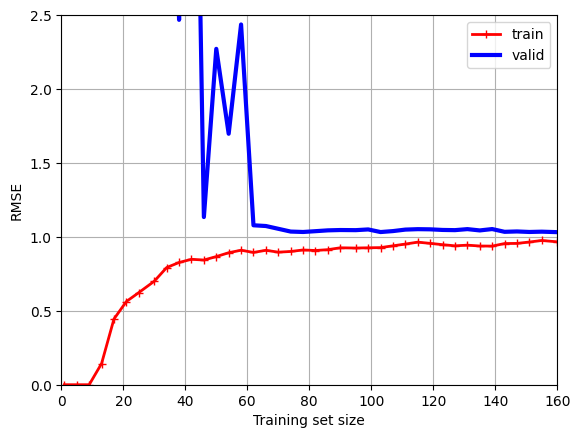

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = make_pipeline(
	# include_bias добавлять ли отдельный столбец из единиц 1; degree степерь возводения
	PolynomialFeatures(degree=10, include_bias=False),
	LinearRegression()
)
# Same with prev

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression,
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.ylabel("RMSE")
plt.xlabel("Training set size")
# axis([xmin, xmax, ymin, ymax]
plt.axis([0, 160, 0, 2.5]) # 160 ширина, сделал как у автора из книги и 2.5
plt.grid(True)
plt.legend()
plt.show()



# Интерпретация: полиномиальная модель переобучена (Overfitting)

*(см. график выше, изображение 3 — красная линия train, синяя линия valid)*

## Похоже на предыдущий график, но есть 2 важных отличия

1. **Ошибка на тренировочных данных намного ниже**, чем была у линейной модели.
2. **Между кривыми есть разрыв (gap)** — модель работает намного лучше на тренировочных данных, чем на валидационных.

## Что это значит

Разрыв между кривыми — это **главный признак переобучения (overfitting)**. Модель настолько сложная и гибкая (10-я степень), что подстраивается почти идеально под конкретные тренировочные точки, включая шум, но плохо обобщает на новые данные.

Если использовать **гораздо больший** тренировочный набор — со временем разрыв между этими двумя кривыми продолжил бы сокращаться (валидационная ошибка постепенно приближалась бы к тренировочной).

## 💡 TIP

Один из способов улучшить переобученную модель — **дать ей больше тренировочных данных**, пока ошибка на валидации не приблизится достаточно близко к ошибке на тренировочных данных.

In [ ]:
# Trade off

# Компромисс Bias/Variance (Bias/Variance Trade-off)

*(см. график выше, изображение 4 — мишени с разбросом предсказаний)*

## Важный теоретический результат

Ошибка обобщения модели (generalization error) раскладывается на сумму **трёх разных источников ошибки**:

## 1. Bias (смещение)

Эта часть ошибки — из-за **неправильных предположений**. Например, предполагаем, что данные линейные, хотя на самом деле они квадратичные.

**Высокий bias** → модель, скорее всего, **недообучена (underfitting)**.

На картинке-мишени: предсказания все сгруппированы плотно, но **далеко от цели (target)** — стабильно, но систематически неверно.

## 2. Variance (разброс/дисперсия)

Эта часть ошибки — из-за **чрезмерной чувствительности** модели к небольшим изменениям в тренировочных данных. Модель с большим числом степеней свободы (например, полином высокой степени) склонна иметь высокий variance и потому **переобучается (overfitting)**.

На картинке-мишени: предсказания разбросаны широко в разные стороны — нестабильно от запуска к запуску.

## 3. Irreducible error (неустранимая ошибка)

Эта часть ошибки — из-за **шума в самих данных**. Единственный способ уменьшить эту часть — **почистить данные** (например, починить неисправные датчики-источники данных, или найти и убрать выбросы/аномалии).

## Компромисс (trade-off)

- **Увеличение сложности модели** → обычно увеличивает variance и уменьшает bias.
- **Уменьшение сложности модели** (или увеличение регуляризации) → увеличивает bias и уменьшает variance.

Именно поэтому это называется "компромисс" (trade-off) — нельзя одновременно уменьшить и то, и другое бесконечно, приходится искать баланс между простотой (высокий bias) и гибкостью (высокий variance) модели.

![4-17-img](./4-17.png)